# TrialOutcome M4 -- SHAP + Error Essay + Multicollinearity + Plain-English Templating

**M9 UPDATE (2026-08-03):** `enrollment_count` was found to be target leakage and dropped
(see `decisions.md` M9-1). **M9-11 UPDATE (2026-08-03):** `sponsor_prior_termination_rate`'s
point-in-time bug fixed (see `decisions.md` M9-11) -- the dataset was rebuilt and the
champion retrained again. Every number in this notebook -- SHAP ranking, worst-20 false
negatives, correlation matrix, plain-English demo -- reflects the current Production
champion, not the M2/M4-original leaked model nor the M9-1-only intermediate one.

This notebook:

1. Refits the current XGBoost champion (M2-selected hyperparameters, M9-11 feature set) +
   isotonic calibrator, matching `notebooks/03_calibration.ipynb`.
2. Loads the TEST and TRAIN feature matrices from **`ml.training_dataset`**, parsing the `features`
   JSONB column into a flat DataFrame (not the raw JSONB blob) -- a genuinely new SQL query this
   session (see query log below), distinct from M3's cached-parquet reconstruction path. A sanity
   check confirms the DB-sourced feature matrix reproduces the identical `pr_auc_temporal`.
3. Computes SHAP values on **TEST only** (never train -- SHAP on train explains overfit behavior,
   not generalization).
4. Runs the Section 4b multicollinearity check on **TRAIN**'s engineered numeric features.
5. Demos `domains/pharma/plain_english.generate_summary` (Section 4a) on 5 sample predictions --
   using the M9-corrected version that partitions factors by SHAP sign (see `decisions.md` M9-3).
6. Writes `docs/error_analysis.md`.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import yaml
from sklearn.metrics import average_precision_score
from sklearn.pipeline import Pipeline
from sqlalchemy import text
from xgboost import XGBClassifier

_REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(_REPO_ROOT))

from core.calibration import CalibratorWrapper
from core.dataset_builder_base import SplitDates
from core.explain import SHAPExplainer
from domains.pharma.dataset_builder import PharmaDatasetBuilder
from domains.pharma.plain_english import generate_summary
from domains.pharma.train_pipeline import (
    CATEGORICAL_FEATURES,
    NUMERIC_FEATURES,
    REPO_ROOT,
    _apply_condition_one_hot,
    _fit_condition_vocab,
    _make_preprocessor,
)

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

/Users/shubhamagrawal/Documents/MS_fall_25/MS_fall_25_uni/ds_projects/trialoutcome/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Refit the XGBoost best trial + isotonic calibrator (reproduces M3 exactly)

Same reconstruction as `notebooks/03_calibration.ipynb`: M2 never logged a model artifact
(`mlflow.sklearn.log_model` was never called), so the best trial is reproduced by refitting its
logged hyperparameters deterministically, not deserializing a saved model.

In [2]:
XGBOOST_BEST_PARAMS = dict(
    n_estimators=452, max_depth=3, learning_rate=0.03442632871923141,
    subsample=0.6455669343594874, colsample_bytree=0.7423738358796874, min_child_weight=3,
)

builder = PharmaDatasetBuilder()
raw = builder.fetch_raw()
feat = builder.build_features(raw)
split_cfg = builder.config["split"]
dates = SplitDates(
    train_end=pd.Timestamp(split_cfg["train_end"]), calib_end=pd.Timestamp(split_cfg["calib_end"])
)
temporal = builder.temporal_split(feat, date_col="start_date", split_dates=dates)
top_conditions = _fit_condition_vocab(temporal[temporal["split"] == "train"])
temporal, condition_cols = _apply_condition_one_hot(temporal, top_conditions)
feature_cols = CATEGORICAL_FEATURES + NUMERIC_FEATURES + condition_cols

train_direct = temporal[temporal["split"] == "train"]
calib_direct = temporal[temporal["split"] == "calib"]

scale_pos_weight = float((train_direct["label"] == 0).sum() / (train_direct["label"] == 1).sum())
clf = XGBClassifier(
    scale_pos_weight=scale_pos_weight, eval_metric="aucpr", random_state=42, n_jobs=-1,
    **XGBOOST_BEST_PARAMS,
)
pipe = Pipeline([("pre", _make_preprocessor(condition_cols)), ("clf", clf)])
pipe.fit(train_direct[feature_cols], train_direct["label"])

proba_calib_raw = pipe.predict_proba(calib_direct[feature_cols])[:, 1]
y_calib = calib_direct["label"].astype(int).to_numpy()
cw = CalibratorWrapper()
cal_result = cw.fit(y_calib, proba_calib_raw)
print(f"Calibration method (matches M3): {cal_result.chosen_method}")

threshold_cfg = yaml.safe_load(open(REPO_ROOT / "domains/pharma/config.yaml"))["model"]["threshold_decision"]
threshold = threshold_cfg["value"]
print(f"Adopted threshold (from config.yaml, computed in M3): {threshold}")

[build_features] 78260 rows after filters. Null rates:
  enrollment_count: 0.0156
  num_primary_outcomes: 0.0350
  num_sites: 0.0841
  allocation: 0.0219
  masking: 0.0231
  has_dmc: 0.2076
  eligibility_criteria: 0.0002
  condition_name: 0.0000
  sponsor_class: 0.0000
  sponsor_prior_termination_rate: 0.0000


Calibration method (matches M3): isotonic
Adopted threshold (from config.yaml, computed in M3): 0.16


## 2. Load TEST + TRAIN feature matrices from `ml.training_dataset` (parse JSONB, not the raw blob)

Query log entry (see `logs/query_log.md` for the persisted copy):

```
## [2026-07-30] [notebooks/04_shap_analysis.ipynb:load_from_training_dataset]
Purpose: reconstruct the TEST-split feature matrix (for SHAP) and TRAIN-split feature matrix
  (for the multicollinearity check) directly from the persisted ml.training_dataset table,
  per M4's explicit instruction to parse the JSONB features column into a flat DataFrame
  rather than reuse the M1/M2 cached raw-feature parquet.
Leakage risk: none -- ml.training_dataset already reflects the leakage-safe point-in-time
  features and split assignment written by M1's dataset_builder.py; this query only reads it.
```

In [3]:
def load_from_training_dataset(engine, splits: list[str]) -> pd.DataFrame:
    with engine.connect() as conn:
        df = pd.read_sql(
            text("SELECT nct_id, features, label, split FROM ml.training_dataset WHERE split = ANY(:splits)"),
            conn,
            params={"splits": splits},
        )
    flat = pd.json_normalize(df["features"])
    return pd.concat([df[["nct_id", "label", "split"]].reset_index(drop=True), flat.reset_index(drop=True)], axis=1)


test_db = load_from_training_dataset(builder.engine, ["test"])
train_db = load_from_training_dataset(builder.engine, ["train"])
print(f"test_db: {test_db.shape}, train_db: {train_db.shape}")

# The M1-build's one-hot condition vocabulary and M2's independently-refit vocabulary agree on
# every condition that actually appears (verified: both top-20-by-frequency on the identical
# underlying data) except 'condition_unknown', which never appears in this dataset at all
# (condition_name null rate is 0.0%) -- M1's get_dummies() never emits an all-zero column for a
# category with zero occurrences, while M2's _apply_condition_one_hot always reindexes it in.
# Reindexing to the fitted pipeline's exact expected columns (fill_value=False) handles this
# correctly regardless.
X_test_db = test_db.reindex(columns=feature_cols, fill_value=False).copy()
for c in condition_cols:
    X_test_db[c] = X_test_db[c].astype(bool)
y_test = test_db["label"].astype(int).to_numpy()

proba_test_db = pipe.predict_proba(X_test_db)[:, 1]
pr_check = average_precision_score(y_test, proba_test_db)
print(f"Sanity check -- pr_auc_temporal on DB-sourced TEST features: {pr_check:.6f} (M9-11 baseline: 0.619294)")
assert abs(pr_check - 0.6192941645955544) < 1e-6, (
    "DB-sourced feature matrix does not match the M9-11 trained pipeline"
)
print("DB-sourced (JSONB-parsed) feature matrix reproduces the M9-11 trained pipeline exactly.")

proba_test_calibrated = cw.predict(proba_test_db, method=cal_result.chosen_method)


test_db: (5789, 39), train_db: (66129, 39)
Sanity check -- pr_auc_temporal on DB-sourced TEST features: 0.619294 (M9-11 baseline: 0.619294)
DB-sourced (JSONB-parsed) feature matrix reproduces the M9-11 trained pipeline exactly.


## 3. SHAP values on TEST

SHAP is computed in the model's actual input space -- after `ColumnTransformer`'s one-hot encoding
of the 5 categorical features (`phase`, `allocation`, `masking`, `has_dmc_str`, `sponsor_class`).
For the global bar chart and beeswarm this is standard SHAP practice (each one-hot dummy gets its
own SHAP value/point). For per-row local explanations feeding
`domains/pharma/plain_english.generate_summary`, a categorical split across several dummy columns
("phase_PHASE2", "phase_PHASE3", ...) is much less readable than one "phase" contribution -- so
those one-hot SHAP values are summed back to their parent original feature below, and the reported
`value` is the trial's actual raw category (e.g. `"PHASE3"`), not a 0/1 dummy.

In [4]:
pre = pipe.named_steps["pre"]
clf_fitted = pipe.named_steps["clf"]
X_test_transformed = pre.transform(X_test_db[feature_cols])
expanded_names = list(pre.get_feature_names_out())
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=expanded_names, index=X_test_db.index).astype(float)

explainer = SHAPExplainer(clf_fitted)
shap_test = explainer.compute_shap_values(X_test_transformed_df)
print(f"shap_test shape: {shap_test.shape}")

global_imp_expanded = explainer.global_importance(shap_test, expanded_names)
global_imp_expanded.head(5)

shap_test shape: (5789, 56)


,feature,mean_abs_shap
0,num__start_year,0.334132
1,num__sponsor_prior_termination_rate,0.327597
2,num__has_results,0.242172
3,num__eligibility_criteria_length,0.141676
4,num__num_sites,0.131309


In [5]:
def original_feature_of(expanded_name: str) -> str:
    if expanded_name.startswith("cat__"):
        rest = expanded_name[len("cat__"):]
        for f in CATEGORICAL_FEATURES:
            if rest.startswith(f + "_"):
                return f
        return rest
    if expanded_name.startswith("num__"):
        return expanded_name[len("num__"):]
    return expanded_name


orig_map = [original_feature_of(n) for n in expanded_names]
_seen: dict[str, list[int]] = {}
for i, of in enumerate(orig_map):
    _seen.setdefault(of, []).append(i)
agg_feature_names = list(_seen.keys())
agg_shap = np.column_stack([shap_test[:, idxs].sum(axis=1) for idxs in _seen.values()])

agg_importance = explainer.global_importance(agg_shap, agg_feature_names)
agg_importance.head(15)

,feature,mean_abs_shap
0,start_year,0.334132
1,sponsor_prior_termination_rate,0.327597
2,has_results,0.242172
3,eligibility_criteria_length,0.141676
4,has_dmc_str,0.135113
5,num_sites,0.131309
6,masking,0.120824
7,phase,0.090234
8,sponsor_prior_trial_count,0.086419
9,num_primary_outcomes,0.067431


### Plot 1: SHAP global importance (bar chart, aggregated to original features, top-20)

Aggregated (not expanded one-hot) names are used here for readability -- this is safe for a
magnitude-only bar chart since no per-sample coloring is needed (unlike the beeswarm below).

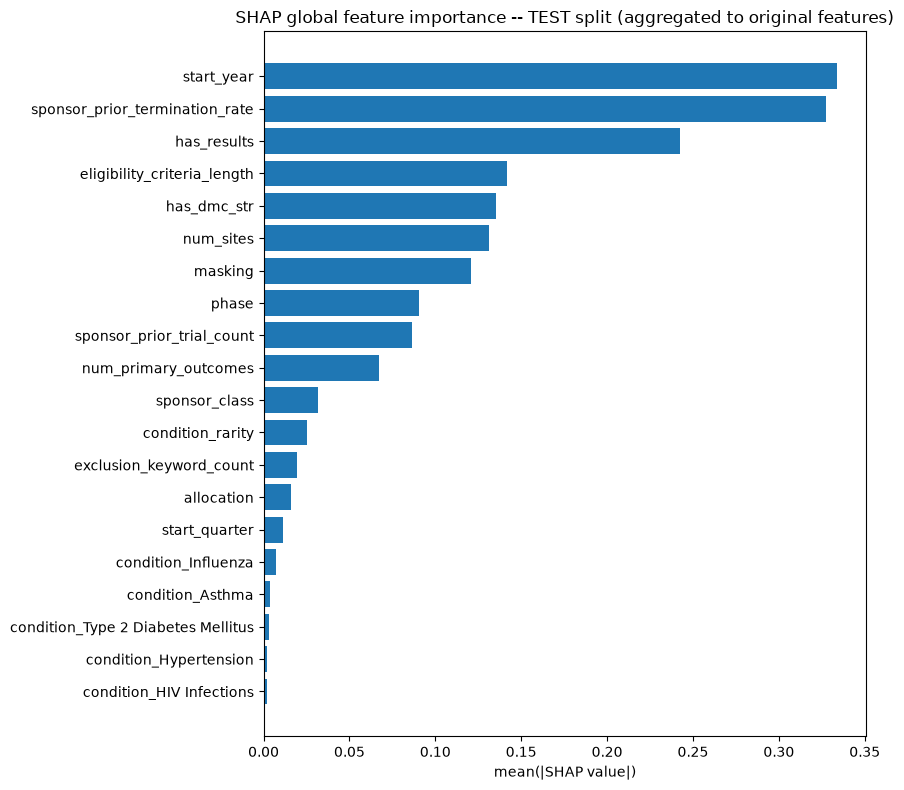

In [6]:
docs_dir = REPO_ROOT / "docs"
docs_dir.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(9, 8))
top20 = agg_importance.head(20).iloc[::-1]
ax.barh(top20["feature"], top20["mean_abs_shap"], color="C0")
ax.set_xlabel("mean(|SHAP value|)")
ax.set_title("SHAP global feature importance -- TEST split (aggregated to original features)")
fig.tight_layout()
fig.savefig(docs_dir / "shap_global_importance.png", dpi=120)
plt.show()

### Plot 2: SHAP beeswarm (direction, not just magnitude)

Uses the expanded (post-`ColumnTransformer`) numeric matrix directly -- `shap.summary_plot`'s
color-by-feature-value encoding needs a numeric matrix aligned 1:1 with the SHAP values array, which
categorical strings in the aggregated space can't provide cleanly.

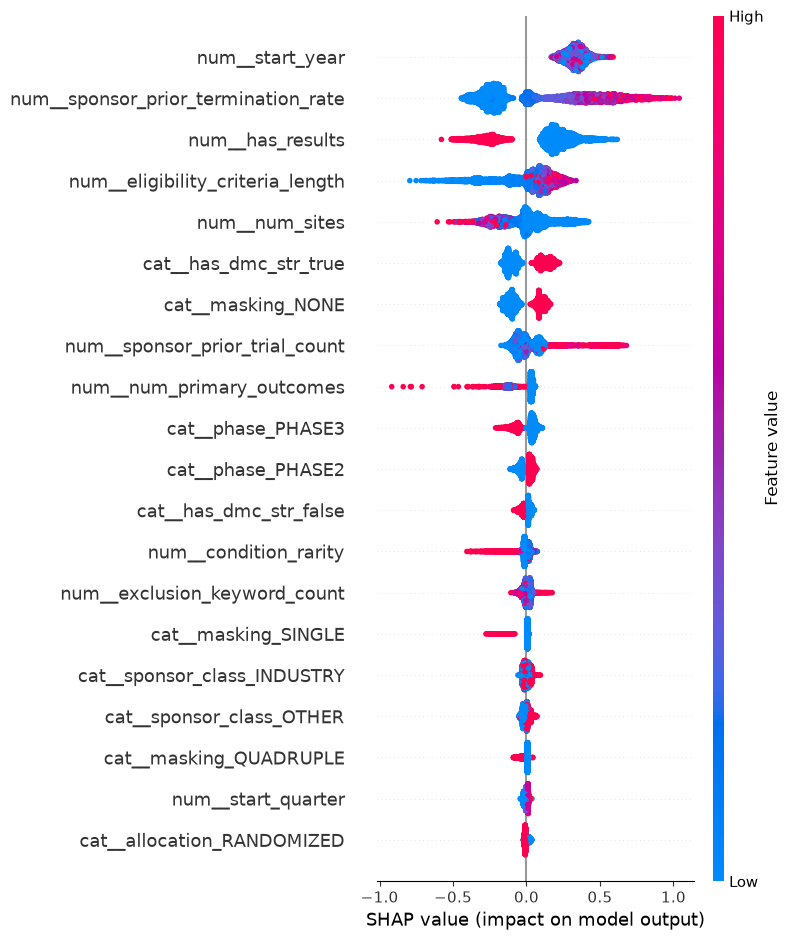

In [7]:
plt.figure(figsize=(9, 8))
shap.summary_plot(shap_test, X_test_transformed_df, max_display=20, show=False)
fig2 = plt.gcf()
fig2.tight_layout()
fig2.savefig(docs_dir / "shap_beeswarm.png", dpi=120, bbox_inches="tight")
plt.show()

In [8]:
print("Top-5 features by mean |SHAP| (expanded model-input space, matches the plots above):\n")
# M9: interpretations rewritten -- log_enrollment_count is gone, and the ranking
# reshuffled substantially (top feature was 4.4x the #2 feature pre-M9; now 1.2x).
interpretations = {
    "num__sponsor_prior_termination_rate": "Now the dominant driver (was #2 pre-M9, behind the leaked enrollment feature). A sponsor's own historical termination rate meaningfully shifts predicted risk, exactly as this point-in-time feature was designed to do -- but see docs/error_analysis.md Theme 1: this also means the model is now substantially a sponsor-reputation model, which has an honest ceiling.",
    "num__start_year": "A temporal signal -- partly a real secular trend (termination base rates rose sharply after 2020: 17.8% pre-2020 vs ~31.7% in the 2022+ test period, decisions.md M1), partly a data-recency artifact (recent trials haven't had time to reach a terminal status).",
    "num__has_results": "Verified non-leaky in M1 (populated pre-completion for a meaningful share of trials), but substantially a reporting-behavior / sponsor-resourcing proxy -- see docs/error_analysis.md Theme 2 for where this pushes the model wrong.",
    "num__eligibility_criteria_length": "Longer eligibility criteria (more inclusion/exclusion detail) is associated with predicted completion -- a design-rigor signal.",
    "num__num_sites": "More sites (more operational redundancy/momentum) pushes toward predicted completion.",
}
for _, row in global_imp_expanded.head(5).iterrows():
    print(f"- {row['feature']} (mean|SHAP|={row['mean_abs_shap']:.4f}): {interpretations.get(row['feature'], '')}")


Top-5 features by mean |SHAP| (expanded model-input space, matches the plots above):

- num__start_year (mean|SHAP|=0.3341): A temporal signal -- partly a real secular trend (termination base rates rose sharply after 2020: 17.8% pre-2020 vs ~31.7% in the 2022+ test period, decisions.md M1), partly a data-recency artifact (recent trials haven't had time to reach a terminal status).
- num__sponsor_prior_termination_rate (mean|SHAP|=0.3276): Now the dominant driver (was #2 pre-M9, behind the leaked enrollment feature). A sponsor's own historical termination rate meaningfully shifts predicted risk, exactly as this point-in-time feature was designed to do -- but see docs/error_analysis.md Theme 1: this also means the model is now substantially a sponsor-reputation model, which has an honest ceiling.
- num__has_results (mean|SHAP|=0.2422): Verified non-leaky in M1 (populated pre-completion for a meaningful share of trials), but substantially a reporting-behavior / sponsor-resourcing proxy --

## 4. Multicollinearity check (TRAIN split, Section 4b)

Pearson correlation across the 9 engineered numeric/ordinal features. (M9: `log_enrollment_count`
is dropped from this list along with the feature it was derived from -- see `decisions.md` M9-1.
Spec Section 4b originally named this feature `enrollment_count_log`; both are now gone.)


In [9]:
NUMERIC_CORR_FEATURES = [
    "num_primary_outcomes", "num_sites",
    "eligibility_criteria_length", "exclusion_keyword_count",
    "sponsor_prior_trial_count", "sponsor_prior_termination_rate",
    "condition_rarity", "start_year", "start_quarter",
]
train_numeric = train_db[NUMERIC_CORR_FEATURES].astype(float)
corr = train_numeric.corr(method="pearson")
corr.round(2)


,num_primary_outcomes,num_sites,eligibility_criteria_length,exclusion_keyword_count,sponsor_prior_trial_count,sponsor_prior_termination_rate,condition_rarity,start_year,start_quarter
num_primary_outcomes,1.00,0.01,0.05,0.04,0.13,0.03,0.02,0.06,0.01
num_sites,0.01,1.00,0.11,0.01,0.18,0.05,0.05,0.05,0.01
eligibility_criteria_length,0.05,0.11,1.00,0.70,0.24,0.13,0.07,0.23,0.02
exclusion_keyword_count,0.04,0.01,0.70,1.00,0.11,0.11,0.05,0.29,0.02
sponsor_prior_trial_count,0.13,0.18,0.24,0.11,1.00,0.17,0.09,0.22,0.02
sponsor_prior_termination_rate,0.03,0.05,0.13,0.11,0.17,1.00,0.07,0.29,0.02
condition_rarity,0.02,0.05,0.07,0.05,0.09,0.07,1.00,0.18,0.01
start_year,0.06,0.05,0.23,0.29,0.22,0.29,0.18,1.00,-0.01
start_quarter,0.01,0.01,0.02,0.02,0.02,0.02,0.01,-0.01,1.00


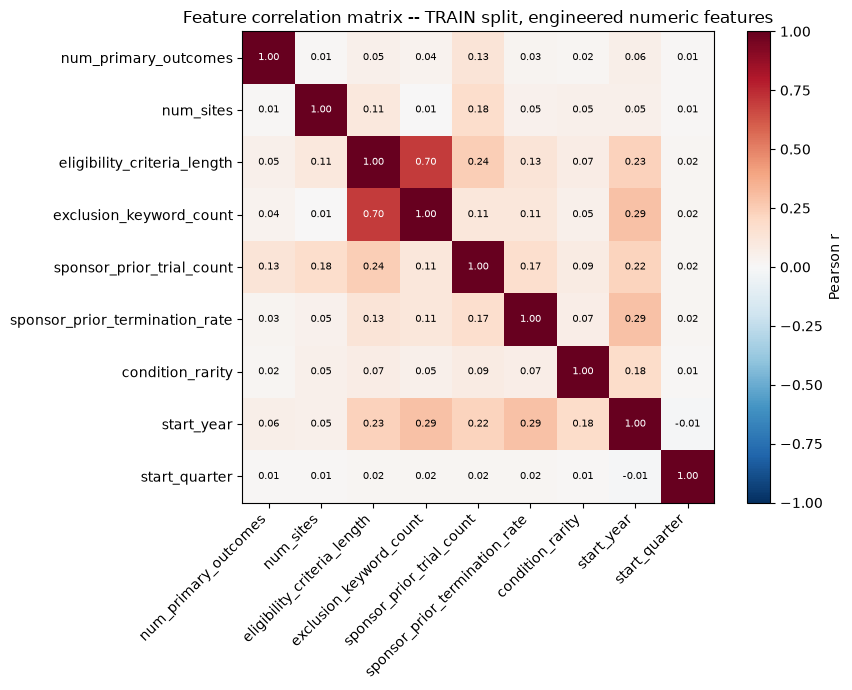

In [10]:
fig3, ax3 = plt.subplots(figsize=(9, 7))
im = ax3.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
ax3.set_xticks(range(len(NUMERIC_CORR_FEATURES)))
ax3.set_xticklabels(NUMERIC_CORR_FEATURES, rotation=45, ha="right")
ax3.set_yticks(range(len(NUMERIC_CORR_FEATURES)))
ax3.set_yticklabels(NUMERIC_CORR_FEATURES)
for i in range(len(NUMERIC_CORR_FEATURES)):
    for j in range(len(NUMERIC_CORR_FEATURES)):
        ax3.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=7,
                  color="white" if abs(corr.values[i, j]) > 0.5 else "black")
fig3.colorbar(im, ax=ax3, label="Pearson r")
ax3.set_title("Feature correlation matrix -- TRAIN split, engineered numeric features")
fig3.tight_layout()
fig3.savefig(docs_dir / "feature_correlation_matrix.png", dpi=120)
plt.show()

In [11]:
pairs = []
for i, a in enumerate(NUMERIC_CORR_FEATURES):
    for b in NUMERIC_CORR_FEATURES[i + 1:]:
        r = corr.loc[a, b]
        if abs(r) > 0.6:
            pairs.append((a, b, float(r)))
print("Pairs with |r| > 0.6:", pairs)

top10_agg = set(agg_importance.head(10)["feature"])
print("\nTop-10 aggregated-SHAP features:", top10_agg)

attribution_caveats = []
for a, b, r in pairs:
    both_top10 = a in top10_agg and b in top10_agg
    print(f"  {a} <-> {b}: r={r:.2f}, both in top-10 SHAP: {both_top10}")
    if both_top10:
        attribution_caveats.append((a, b, r))

if attribution_caveats:
    for a, b, r in attribution_caveats:
        print(f"CAVEAT: attribution is shared between correlated signals -- SHAP values for {a} and {b} "
              f"should not be read in isolation (r={r:.2f}).")
else:
    ranks = {f: i + 1 for i, f in enumerate(agg_importance["feature"].tolist())}
    print("\nNo flagged pair has BOTH members in the top-10 SHAP features in this build.")
    for a, b, r in pairs:
        print(f"  {a}: rank {ranks.get(a, 'n/a')}   {b}: rank {ranks.get(b, 'n/a')}")
    print("(M9: eligibility_criteria_length moved up to rank 4 when enrollment left -- closer to "
          "the top-10 cutoff than pre-M9's rank 10. Re-check this on every retrain.)")


Pairs with |r| > 0.6: [('eligibility_criteria_length', 'exclusion_keyword_count', 0.6970694479312188)]

Top-10 aggregated-SHAP features: {'start_year', 'phase', 'has_results', 'masking', 'sponsor_prior_trial_count', 'num_primary_outcomes', 'has_dmc_str', 'num_sites', 'sponsor_prior_termination_rate', 'eligibility_criteria_length'}
  eligibility_criteria_length <-> exclusion_keyword_count: r=0.70, both in top-10 SHAP: False

No flagged pair has BOTH members in the top-10 SHAP features in this build.
  eligibility_criteria_length: rank 4   exclusion_keyword_count: rank 13
(M9: eligibility_criteria_length moved up to rank 4 when enrollment left -- closer to the top-10 cutoff than pre-M9's rank 10. Re-check this on every retrain.)


## 5. Worst 20 false negatives

Highest predicted probability of *success* (lowest calibrated proba) among trials that actually
terminated -- the model's most confident wrong misses.

In [12]:
X_test_orig = X_test_db[feature_cols].reset_index(drop=True)
wfn = explainer.worst_false_negatives(X_test_orig, y_test, proba_test_calibrated, threshold=threshold, n=20)
print(f"{len(wfn)} worst false negatives found (threshold={threshold}).")


def local_explanation_aggregated(row_idx: int, top_n: int = 6) -> list[dict]:
    row_shap = agg_shap[row_idx]
    order = np.argsort(-np.abs(row_shap))[:top_n]
    return [
        {
            "feature": agg_feature_names[i],
            "value": X_test_orig.iloc[row_idx][agg_feature_names[i]],
            "shap_contribution": float(row_shap[i]),
        }
        for i in order
    ]


wfn_rows = []
for ridx in wfn["row_index"]:
    local = local_explanation_aggregated(ridx, top_n=6)
    proba = float(proba_test_calibrated[ridx])
    summary = generate_summary(local, "LOW RISK (missed)", proba)
    wfn_rows.append(
        {
            "nct_id": test_db.iloc[ridx]["nct_id"],
            "proba": proba,
            "true_label": 1,
            "top_shap_feature": local[0]["feature"],
            "plain_english_summary": summary,
            "phase": X_test_orig.iloc[ridx]["phase"],
            "sponsor_prior_termination_rate": X_test_orig.iloc[ridx]["sponsor_prior_termination_rate"],
            "sponsor_prior_trial_count": X_test_orig.iloc[ridx]["sponsor_prior_trial_count"],
            "num_sites": X_test_orig.iloc[ridx]["num_sites"],
        }
    )
wfn_df = pd.DataFrame(wfn_rows)
pd.set_option("display.max_colwidth", 120)
wfn_df


20 worst false negatives found (threshold=0.16).


,nct_id,proba,true_label,top_shap_feature,plain_english_summary,phase,sponsor_prior_termination_rate,sponsor_prior_trial_count,num_sites
0,NCT05398263,0.022472,1,has_results,This trial is flagged LOW RISK (missed) (2% estimated termination probability) primarily because: (1) has_results is...,PHASE3,0.056268,2808,64.0
1,NCT06128369,0.022472,1,start_year,This trial is flagged LOW RISK (missed) (2% estimated termination probability) primarily because: (1) has_results is...,PHASE3,0.000000,6,24.0
2,NCT05681481,0.058480,1,start_year,This trial is flagged LOW RISK (missed) (6% estimated termination probability) primarily because: (1) has_results is...,PHASE3,0.000000,36,40.0
3,NCT05694611,0.058480,1,eligibility_criteria_length,This trial is flagged LOW RISK (missed) (6% estimated termination probability) primarily because: (1) eligibility cr...,PHASE3,0.023715,253,1.0
4,NCT05513391,0.058480,1,start_year,This trial is flagged LOW RISK (missed) (6% estimated termination probability) primarily because: (1) has_results is...,PHASE3,0.035821,335,31.0
5,NCT05967130,0.058480,1,eligibility_criteria_length,This trial is flagged LOW RISK (missed) (6% estimated termination probability) primarily because: (1) eligibility cr...,PHASE3,0.005291,189,1.0
6,NCT06301308,0.058480,1,sponsor_prior_termination_rate,This trial is flagged LOW RISK (missed) (6% estimated termination probability) primarily because: (1) the sponsor's ...,PHASE3,0.000000,51,1.0
7,NCT06077773,0.063492,1,start_year,This trial is flagged LOW RISK (missed) (6% estimated termination probability) primarily because: (1) the sponsor's ...,PHASE2,0.000000,3,48.0
8,NCT06400589,0.063492,1,sponsor_prior_termination_rate,This trial is flagged LOW RISK (missed) (6% estimated termination probability) primarily because: (1) the sponsor's ...,PHASE3,0.000000,14,1.0
9,NCT06104683,0.063492,1,start_year,This trial is flagged LOW RISK (missed) (6% estimated termination probability) primarily because: (1) the sponsor's ...,PHASE2,0.000000,14,4.0


In [13]:
low_hist = int((wfn_df["sponsor_prior_termination_rate"] < 0.06).sum())
mega_sponsor = int((wfn_df["sponsor_prior_trial_count"] >= 200).sum())
single_site = int((wfn_df["num_sites"] <= 1).sum())
print(f"Of the 20 worst false negatives (M9 no-enrollment model):")
print(f"  {low_hist}/20 have sponsor_prior_termination_rate < 6% (well below the training median)")
print(f"  {mega_sponsor}/20 have sponsor_prior_trial_count >= 200 ('mega-sponsors')")
print(f"  {single_site}/20 have num_sites <= 1 (single/near-single-site trials)")
print(f"\nSee docs/error_analysis.md for the M9 failure-theme rewrite -- the pre-M9 three themes "
      f"(mega-sponsors / single-site / no-extreme-feature) no longer describe this model; the new "
      f"themes are organized around sponsor-record dominance, has_results-at-mega-sponsors, and "
      f"recency.")


Of the 20 worst false negatives (M9 no-enrollment model):
  15/20 have sponsor_prior_termination_rate < 6% (well below the training median)
  7/20 have sponsor_prior_trial_count >= 200 ('mega-sponsors')
  5/20 have num_sites <= 1 (single/near-single-site trials)

See docs/error_analysis.md for the M9 failure-theme rewrite -- the pre-M9 three themes (mega-sponsors / single-site / no-extreme-feature) no longer describe this model; the new themes are organized around sponsor-record dominance, has_results-at-mega-sponsors, and recency.


## 6. Plain-English demo (Section 4a) -- 2 high-risk TP, 2 low-risk TN, 1 worst FN

In [14]:
y_pred = (proba_test_calibrated >= threshold).astype(int)
is_tp = (y_test == 1) & (y_pred == 1)
is_tn = (y_test == 0) & (y_pred == 0)
tp_idx = np.where(is_tp)[0]
tn_idx = np.where(is_tn)[0]
top2_tp = tp_idx[np.argsort(-proba_test_calibrated[tp_idx])][:2]
top2_tn = tn_idx[np.argsort(proba_test_calibrated[tn_idx])][:2]
worst_fn_idx = int(wfn["row_index"].iloc[0])

demo_summaries = []
for label, idx in [
    ("TP #1 (highest-confidence correct HIGH RISK call)", top2_tp[0]),
    ("TP #2 (2nd highest-confidence correct HIGH RISK call)", top2_tp[1]),
    ("TN #1 (highest-confidence correct LOW RISK call)", top2_tn[0]),
    ("TN #2 (2nd highest-confidence correct LOW RISK call)", top2_tn[1]),
    ("FN (worst miss)", worst_fn_idx),
]:
    local = local_explanation_aggregated(int(idx), top_n=3)
    proba = float(proba_test_calibrated[idx])
    decision = "HIGH RISK" if proba >= threshold else "LOW RISK"
    summary = generate_summary(local, decision, proba)
    demo_summaries.append((label, test_db.iloc[idx]["nct_id"], int(y_test[idx]), proba, summary))
    print(f"[{label}]")
    print(f"  nct_id={test_db.iloc[idx]['nct_id']}  true_label={int(y_test[idx])}  proba={proba:.3f}")
    print(f"  {summary}\n")

[TP #1 (highest-confidence correct HIGH RISK call)]
  nct_id=NCT06522360  true_label=1  proba=1.000
  This trial is flagged HIGH RISK (100% estimated termination probability) primarily because: (1) the sponsor's prior termination rate is 16%, which is roughly typical for the training population, (2) the sponsor has run 2756 prior trials -- an experienced sponsor with an established track record, (3) has_results is False (above average).

[TP #2 (2nd highest-confidence correct HIGH RISK call)]
  nct_id=NCT05363709  true_label=1  proba=1.000
  This trial is flagged HIGH RISK (100% estimated termination probability) primarily because: (1) the sponsor's prior termination rate is 15%, which is roughly typical for the training population, (2) the sponsor has run 2614 prior trials -- an experienced sponsor with an established track record, (3) has_results is False (above average).

[TN #1 (highest-confidence correct LOW RISK call)]
  nct_id=NCT05523089  true_label=0  proba=0.004
  This trial 

## Why this, not that

- **Aggregating one-hot SHAP back to original features for local explanations, but not for the
  beeswarm:** the beeswarm needs a numeric matrix aligned to the SHAP array for its color-by-value
  encoding, which the mixed-type aggregated space can't provide; local explanations feed a
  plain-English sentence, where "phase" as one concept is what a reader needs, not three separate
  dummy contributions. **Failure mode if this split weren't made:** either a beeswarm that can't
  color categorical points meaningfully, or a plain-English summary that reads "phase_PHASE3 is 1.0"
  instead of "this is a Phase 3 trial." **Trigger to reconsider:** if a future feature has enough
  one-hot levels that summing loses meaningful nuance (e.g., a 100-category feature), aggregation
  would need a different rollup (e.g., keep the single strongest level instead of summing all).
  **10x/100x scale:** aggregation is a single groupby-sum over SHAP's output columns -- cost scales
  with feature count, not row count, so this is unaffected by 10x/100x more trials.
- **worst_false_negatives ranks by lowest calibrated probability, not raw model score:** using raw
  XGBoost output here would rank misses by a script that's demonstrably miscalibrated (M3: raw TEST
  ECE 0.19 vs 0.02 calibrated) -- "most confident" should mean the number a downstream consumer
  (RegIntel's `trial_risk` tool, per the locked API contract) would actually see. **Failure mode:**
  ranking by raw score could surface a miss that's `no longer` the model's most confident wrong
  answer post-calibration, misleading the error essay's theme-finding. **Trigger to reconsider:** if
  a future milestone swaps calibration methods, this ranking must be recomputed with the new
  calibrated probabilities, not reused. **10x/100x scale:** ranking is an O(n log n) sort over the
  TEST split -- trivial at any realistic scale.